# 4. Modeling

## 4.1 Select Modeling Techniques

Different algorithms were selected to test different modeling approaches and compare their ability to identify potential responders.

The following models were chosen:

- **Logistic Regression** was used as a baseline model because it is simple and provides an initial reference point for performance comparison.

- **Decision Tree** was selected because it can capture non-linear relationships and produce easily interpretable decision rules.

- **Random Forest** was included to test whether combining multiple trees could improve prediction performance and reduce overfitting.

- **Gradient Boosting** was selected because boosting methods often perform well in this type of datasets and can improve prediction quality by focusing on previous model errors.

In [44]:
# importing libraries
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import (GradientBoostingClassifier,RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay,PrecisionRecallDisplay,RocCurveDisplay,
    accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [45]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
X_train_scaled = pd.read_csv("../data/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/X_test_scaled.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

## 4.2 Generate Test Design

The training and testing datasets were created during the Data Preparation phase using a stratified train-test split. Stratification preserved approximately the same proportion of responders and non-responders in both datasets.

Two versions of the predictor data were used:

- Scaled datasets (`X_train_scaled` and `X_test_scaled`) for Logistic Regression.
- Non-scaled datasets (`X_train` and `X_test`) for Decision Tree, Random Forest, and Gradient Boosting.

The test set remained completely unchanged and was used only for final model evaluation.

Because the target variable is imbalanced, particular attention was given to:

- **Recall**, which measures the proportion of actual responders correctly identified.
- **Precision**, which measures how many customers predicted as responders actually responded.
- **F1-score**, which balances Precision and Recall.
- **ROC-AUC**, which measures the model's ability to rank responders above non-responders across different classification thresholds.

Accuracy was also reported, but it was not used as the main model-selection criterion because the majority of customers did not respond to the campaign.

### Class balance verification

Since the target variable is imbalanced, the class distribution in the training set was examined before applying any balancing techniques.

Counter({0: 1520, 1: 266})


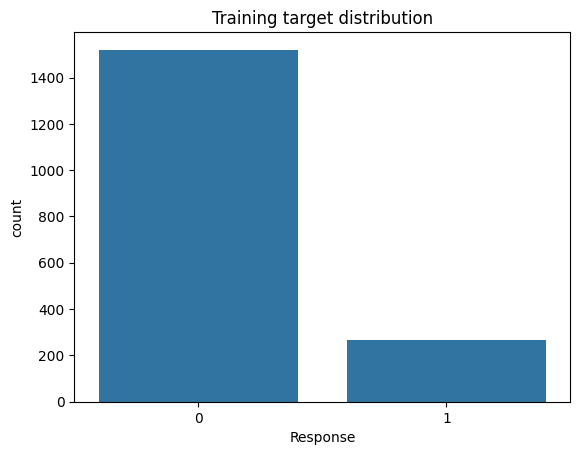

In [46]:
print(Counter(y_train))

sns.countplot(x=y_train)
plt.title('Training target distribution')
plt.show()

### Handling Class Imbalance

The training set showed a clear class imbalance:

* Non-responders (`Response = 0`): **1,520**
* Responders (`Response = 1`): **266**

Only approximately **14.9%** of the training observations belonged to the responder class.

SMOTE was applied only to the training data used for the initial baseline models. The test set remained unchanged.

For hyperparameter tuning, the original training data was used. Class weighting was included among the parameters tested for Logistic Regression, Decision Tree, and Random Forest.


Before SMOTE: Counter({0: 1520, 1: 266})
After SMOTE: Counter({0: 1520, 1: 1520})


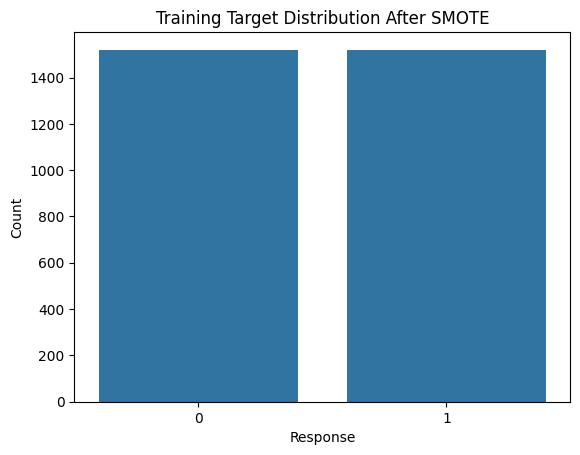

In [47]:
sm = SMOTE(random_state=42, sampling_strategy=1.0)

# on non-scaled training data
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# on scaled training data
X_train_scaled_sm, y_train_scaled_sm = sm.fit_resample(X_train_scaled, y_train)

# class distribution
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_sm))

sns.countplot(x=y_train_sm)
plt.title("Training Target Distribution After SMOTE")
plt.xlabel("Response")
plt.ylabel("Count")
plt.show()

## 4.3 Build Models

### 4.3.1 Logistic Regression

Logistic Regression was used as a baseline model to provide an initial performance reference for comparison with more complex algorithms.

Since this model is sensitive to feature scale and class imbalance, the scaled training data with SMOTE (`X_train_scaled_sm`) was used. This approach was selected to improve the model's ability to identify customers from the minority responder class.

In [48]:
log_reg = LogisticRegression(
    max_iter=5000,
    solver='liblinear',
    random_state=42
)

log_reg.fit(X_train_scaled_sm, y_train_scaled_sm)

y_pred_log = log_reg.predict(X_test_scaled)

# probabilities for ROC-AUC
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# results
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_log))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       381
           1       0.51      0.55      0.53        66

    accuracy                           0.85       447
   macro avg       0.71      0.73      0.72       447
weighted avg       0.86      0.85      0.86       447

Confusion Matrix
[[346  35]
 [ 30  36]]
ROC-AUC Score: 0.8706752565020281


### Logistic Regression Results

The baseline Logistic Regression model achieved:

* Accuracy: **0.85**
* Precision: **0.51**
* Recall: **0.55**
* F1-score: **0.53**
* ROC-AUC: **0.87**

The model correctly identified **36 of the 66 actual responders**.

It produced **35 false positives** and missed **30 responders**.


### Logistic Regression hyperparameter tuning

Hyperparameter tuning was performed using the original scaled training data.

The regularisation strength and class-weight configuration were tested using GridSearchCV. F1-score was used as the optimisation metric because the target variable is imbalanced and both Precision and Recall are important.

Best parameters: {'C': 0.1, 'class_weight': 'balanced'}
Best CV F1-score: 0.5646246963957859

Classification Report - Tuned Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       381
           1       0.45      0.74      0.56        66

    accuracy                           0.83       447
   macro avg       0.70      0.79      0.72       447
weighted avg       0.88      0.83      0.84       447



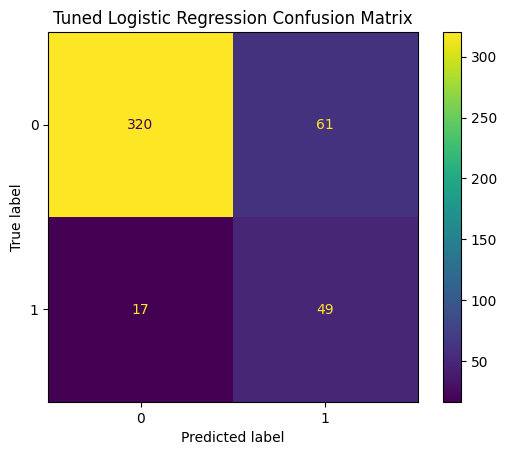

ROC-AUC Score: 0.9006203769983298


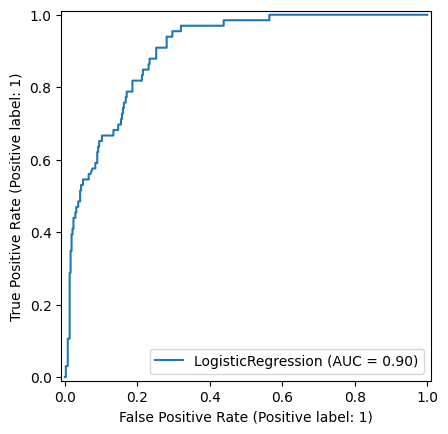

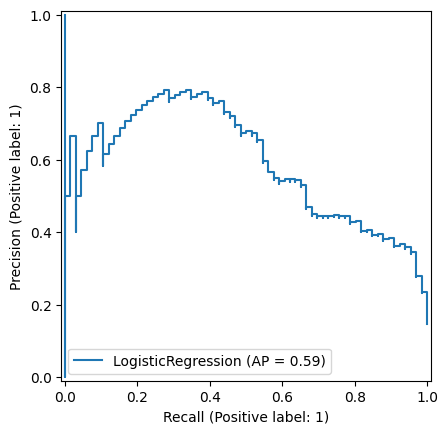

In [49]:
param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"]
}

grid_log = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        random_state=42
    ),
    param_grid=param_grid_log,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_log.fit(
    X_train_scaled,
    y_train
)

best_log = grid_log.best_estimator_

y_pred_best_log = best_log.predict(X_test_scaled)
y_prob_best_log = best_log.predict_proba(
    X_test_scaled
)[:, 1]

print("Best parameters:", grid_log.best_params_)
print("Best CV F1-score:", grid_log.best_score_)

print("\nClassification Report - Tuned Logistic Regression")
print(classification_report(y_test, y_pred_best_log))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best_log
)
plt.title("Tuned Logistic Regression Confusion Matrix")
plt.show()

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, y_prob_best_log)
)

RocCurveDisplay.from_estimator(
    best_log,
    X_test_scaled,
    y_test
)
plt.show()

PrecisionRecallDisplay.from_estimator(
    best_log,
    X_test_scaled,
    y_test
)
plt.show()

### Tuned Logistic Regression Results

The best configuration selected by GridSearchCV was:

* `C = 0.1`
* `class_weight = balanced`

The tuned Logistic Regression model achieved:

* Accuracy: **0.83**
* Precision: **0.45**
* Recall: **0.74**
* F1-score: **0.56**
* Cross-validation F1-score: **0.56**
* ROC-AUC: **0.90**

The model correctly identified **49 of the 66 actual responders**.

It produced **61 false positives** and missed **17 responders**.


### 4.3.2 Decision Tree

Decision Tree was selected to test whether a more flexible model could capture patterns and interactions that Logistic Regression couldn't.

Since Decision Trees are not sensitive to variable scale, the non-scaled datasets were used. The model was trained using the SMOTE-balanced training data because earlier tests showed improved performance when handling class imbalance.

Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       381
           1       0.33      0.59      0.42        66

    accuracy                           0.76       447
   macro avg       0.62      0.69      0.64       447
weighted avg       0.83      0.76      0.79       447



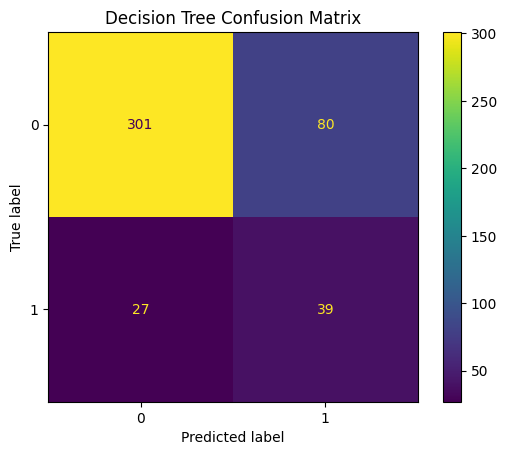

ROC-AUC Score: 0.7584108804581247


In [50]:
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)

tree_model.fit(X_train_sm, y_train_sm)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)

plt.title("Decision Tree Confusion Matrix")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_tree))

### Decision Tree Results

The baseline Decision Tree model achieved:

* Accuracy: **0.76**
* Precision: **0.33**
* Recall: **0.59**
* F1-score: **0.42**
* ROC-AUC: **0.76**

The model correctly identified **39 of the 66 actual responders**.

It produced **80 false positives** and missed **27 responders**.


### Decision Tree hyperparameter tuning

Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1-score: 0.518857416951774
Classification Report - Tuned Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       381
           1       0.50      0.41      0.45        66

    accuracy                           0.85       447
   macro avg       0.70      0.67      0.68       447
weighted avg       0.84      0.85      0.85       447



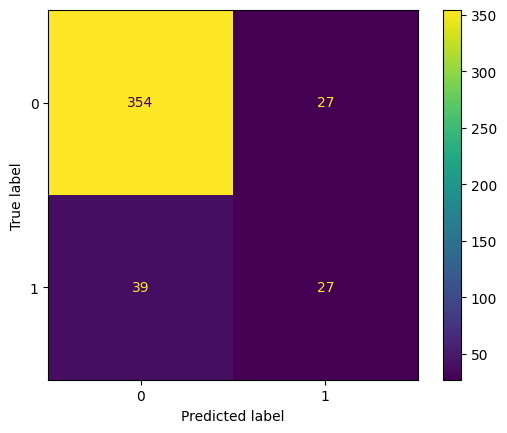

ROC-AUC Score: 0.7780760359500517


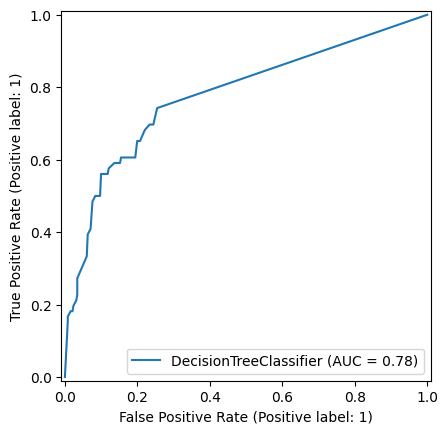

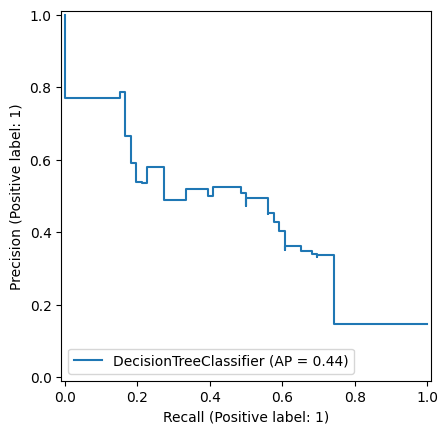

In [51]:
param_grid_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': [None, 'balanced']
}

grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_tree,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

# best parameters
print("Best parameters:", grid_tree.best_params_)
print("Best CV F1-score:", grid_tree.best_score_)

# best model
best_tree = grid_tree.best_estimator_

y_pred_best_tree = best_tree.predict(X_test)
y_prob_best_tree = best_tree.predict_proba(X_test)[:, 1]

# results
print("Classification Report - Tuned Decision Tree")
print(classification_report(y_test, y_pred_best_tree))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_tree)
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_best_tree))
RocCurveDisplay.from_estimator(best_tree, X_test, y_test)
plt.show()

PrecisionRecallDisplay.from_estimator(best_tree, X_test, y_test)
plt.show()

### Tuned Decision Tree Results

The tuned Decision Tree model achieved:

* Accuracy: **0.85**
* Precision: **0.50**
* Recall: **0.41**
* F1-score: **0.45**
* Cross-validation F1-score: **0.52**
* ROC-AUC: **0.78**

The model correctly identified **27 of the 66 actual responders**.

It produced **27 false positives** and missed **39 responders**.


### 4.3.3 Random Forest

Since earlier tests showed improvements from SMOTE for tree-based models, the model was trained using the SMOTE-balanced non-scaled training data (`X_train_sm`).

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       381
           1       0.49      0.61      0.54        66

    accuracy                           0.85       447
   macro avg       0.71      0.75      0.73       447
weighted avg       0.86      0.85      0.86       447



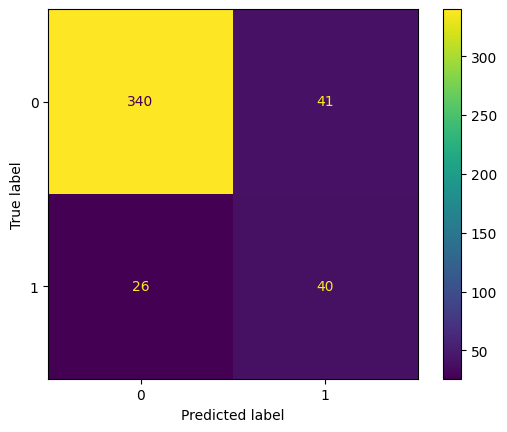

ROC-AUC Score: 0.8582677165354331


In [52]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf = rf_model.predict(X_test)

# ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# results
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

### Random Forest Results

The baseline Random Forest model achieved:

* Accuracy: **0.85**
* Precision: **0.49**
* Recall: **0.61**
* F1-score: **0.54**
* ROC-AUC: **0.86**

The model correctly identified **40 of the 66 actual responders**.

It produced **41 false positives** and missed **26 responders**.


### Random Forest hyperparameter tuning

Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score: 0.5905913513460683

Classification Report - Tuned Random Forest
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       381
           1       0.53      0.52      0.52        66

    accuracy                           0.86       447
   macro avg       0.72      0.72      0.72       447
weighted avg       0.86      0.86      0.86       447



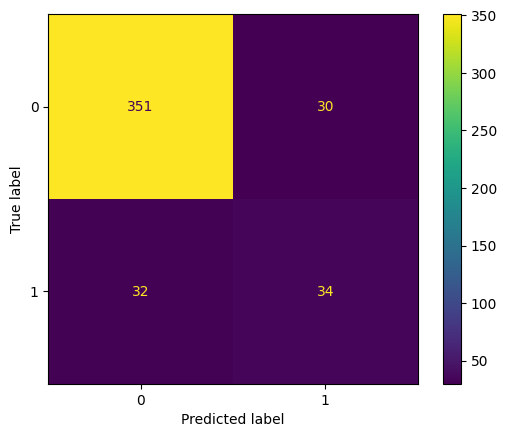

ROC-AUC Score: 0.8792253241072139


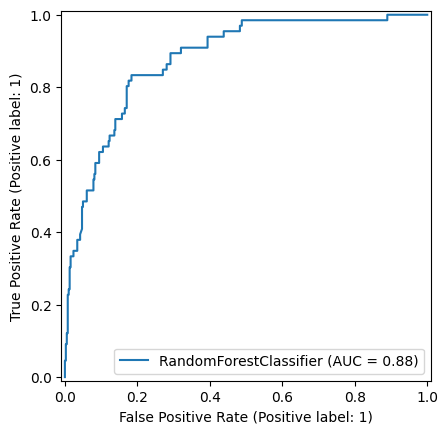

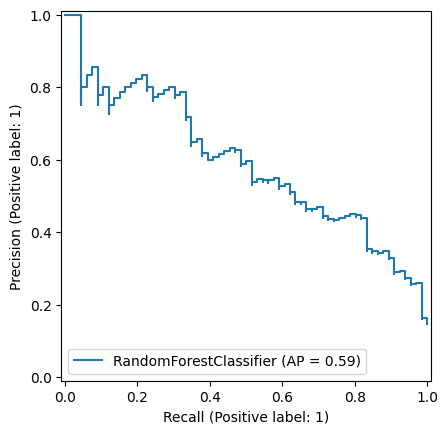

In [53]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_


print("Best parameters:", grid_rf.best_params_)
print("Best CV F1-score:", grid_rf.best_score_)


y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

# results
print("\nClassification Report - Tuned Random Forest")
print(classification_report(y_test, y_pred_best_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_rf)
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_best_rf))
RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.show()

PrecisionRecallDisplay.from_estimator(best_rf, X_test, y_test)
plt.show()

### Tuned Random Forest Results

The tuned Random Forest model achieved:

* Accuracy: **0.86**
* Precision: **0.53**
* Recall: **0.52**
* F1-score: **0.52**
* Cross-validation F1-score: **0.59**
* ROC-AUC: **0.88**

The model correctly identified **34 of the 66 actual responders**.

It produced **30 false positives** and missed **32 responders**.


### Feature Importance in Analysis

,Feature,Importance
3,Recency,0.108285
25,Accepted_Total,0.104684
22,Seniority,0.098402
23,Total_Spending,0.065191
9,MntGoldProds,0.059279
0,Income,0.053575
6,MntMeatProducts,0.049857
4,MntWines,0.040295
15,AcceptedCmp3,0.039110
17,AcceptedCmp5,0.035848


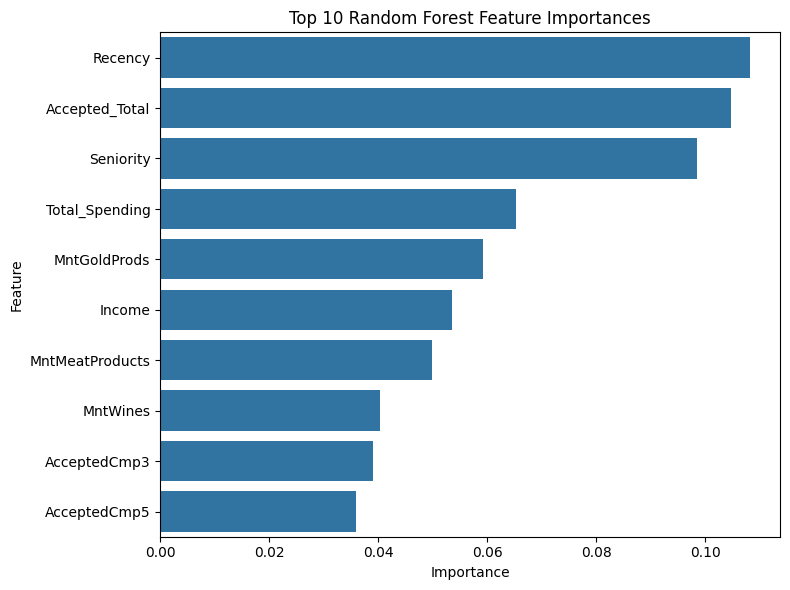

In [54]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance.head(10))

plt.figure(figsize=(8, 6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

#### Key Findings:

The most important predictors identified by the tuned Random Forest model were mainly related to:

* recent customer activity;
* product spending;
* customer seniority;
* previous campaign responses;
* purchasing behaviour.

The highest-ranked variables included `Recency`, spending-related features, `Seniority`, and previous campaign acceptance variables.


### 4.3.4 Gradient Boosting

Gradient Boosting was selected to test whether a boosting approach could improve prediction performance by focusing on patterns missed by previous models. SMOTE was initially tested during experimentation. However, Gradient Boosting achieved stronger results using the original training data, so the final model was trained on the non-scaled non-balanced dataset (`X_train`).

Since Gradient Boosting is a tree-based model, feature scaling was not required.

Classification Report - Gradient Boosting
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       381
           1       0.78      0.38      0.51        66

    accuracy                           0.89       447
   macro avg       0.84      0.68      0.72       447
weighted avg       0.88      0.89      0.88       447



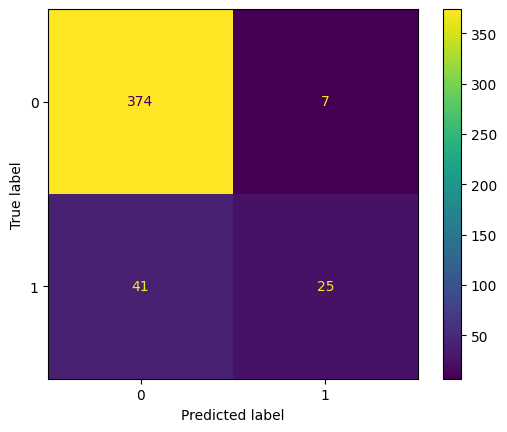

ROC-AUC Score: 0.8973594209814683


In [55]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

# ROC-AUC
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Classification Report - Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb)
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_gb))

### Gradient Boosting Results

The baseline Gradient Boosting model achieved:

* Accuracy: **0.89**
* Precision: **0.78**
* Recall: **0.38**
* F1-score: **0.51**
* ROC-AUC: **0.90**

The model correctly identified **25 of the 66 actual responders**.

It produced **7 false positives** and missed **41 responders**.


### Gradient Boosting hyperparameter tuning

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score: 0.5973254458146033

Classification Report - Tuned Gradient Boosting
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       381
           1       0.73      0.45      0.56        66

    accuracy                           0.89       447
   macro avg       0.82      0.71      0.75       447
weighted avg       0.88      0.89      0.88       447



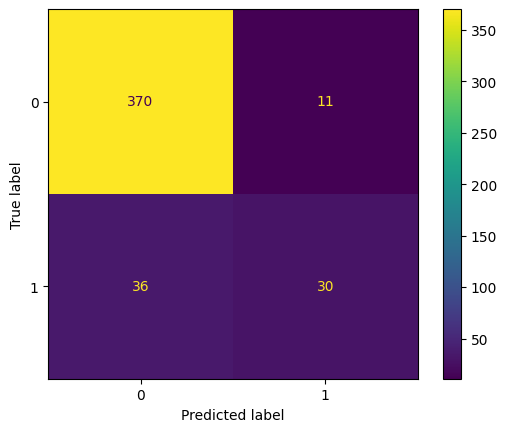

ROC-AUC Score: 0.9021315517378511


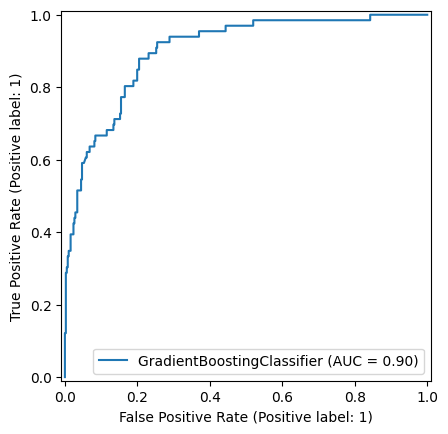

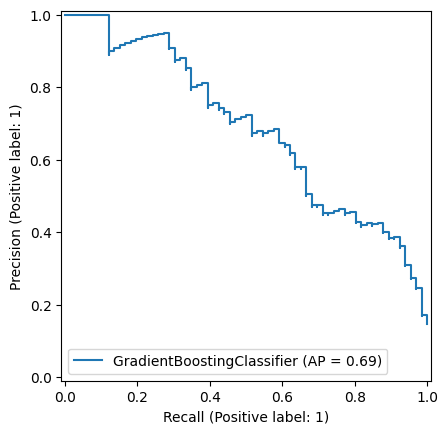

In [56]:
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

# best model
best_gb = grid_gb.best_estimator_

print("Best parameters:", grid_gb.best_params_)
print("Best CV F1-score:", grid_gb.best_score_)

y_pred_best_gb = best_gb.predict(X_test)
y_prob_best_gb = best_gb.predict_proba(X_test)[:, 1]

# results
print("\nClassification Report - Tuned Gradient Boosting")
print(classification_report(y_test, y_pred_best_gb))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_gb)
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_best_gb))
RocCurveDisplay.from_estimator(best_gb, X_test, y_test)
plt.show()

PrecisionRecallDisplay.from_estimator(best_gb, X_test, y_test)
plt.show()

### Tuned Gradient Boosting Results

The tuned Gradient Boosting model achieved:

* Accuracy: **0.89**
* Precision: **0.73**
* Recall: **0.45**
* F1-score: **0.56**
* Cross-validation F1-score: **0.60**
* ROC-AUC: **0.90**

The model correctly identified **30 of the 66 actual responders**.

It produced **11 false positives** and missed **36 responders**.


## 4.4 Model Assessment

#### Model Comparison

The models showed different strengths across the evaluation metrics.

* **Tuned Logistic Regression** achieved the highest Recall at **0.74**.
* **Gradient Boosting** achieved the highest Precision at **0.78**.
* **Tuned Gradient Boosting** achieved the highest F1-score at **0.56** and the highest ROC-AUC at **0.90**.
* **Random Forest** also produced a relatively balanced result, with Recall of **0.61** and F1-score of **0.54**.

Based on the overall comparison, **Tuned Gradient Boosting** was selected as the final model.


### Summary of Model Performance

The complete model results are summarised in the table below.

The table includes:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Confusion-matrix values
* Cross-validation F1-score for the tuned models

The models are ordered by test-set F1-score.


In [57]:
def evaluate_model(model_name, y_true, y_pred, y_prob, best_params=None, cv_f1=None, data_used=None, balancing=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    return {
        "Model": model_name,
        "Data used": data_used,
        "Balancing": balancing,
        "Best parameters": best_params,
        "CV F1": cv_f1,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_1": precision_score(y_true, y_pred, pos_label=1),
        "Recall_1": recall_score(y_true, y_pred, pos_label=1),
        "F1_1": f1_score(y_true, y_pred, pos_label=1),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


model_results = []

# Logistic Regression
model_results.append(evaluate_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=y_pred_log,
    y_prob=y_prob_log,
    data_used="Scaled data",
    balancing="SMOTE on training set",
    best_params=log_reg.get_params(),
    cv_f1=None
))

# Tuned Logistic Regression
model_results.append(evaluate_model(
    model_name="Tuned Logistic Regression",
    y_true=y_test,
    y_pred=y_pred_best_log,
    y_prob=y_prob_best_log,
    data_used="Scaled data",
    balancing="Class weight tested during tuning",
    best_params=grid_log.best_params_,
    cv_f1=grid_log.best_score_
))

# Decision Tree
model_results.append(evaluate_model(
    model_name="Decision Tree",
    y_true=y_test,
    y_pred=y_pred_tree,
    y_prob=y_prob_tree,
    data_used="Non-scaled data",
    balancing="SMOTE on training set",
    best_params=tree_model.get_params(),
    cv_f1=None
))

# Tuned Decision Tree
model_results.append(evaluate_model(
    model_name="Tuned Decision Tree",
    y_true=y_test,
    y_pred=y_pred_best_tree,
    y_prob=y_prob_best_tree,
    data_used="Non-scaled data",
    balancing="Class weight tested during tuning",
    best_params=grid_tree.best_params_,
    cv_f1=grid_tree.best_score_
))

# Random Forest
model_results.append(evaluate_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=y_pred_rf,
    y_prob=y_prob_rf,
    data_used="Non-scaled data",
    balancing="SMOTE on training set",
    best_params=rf_model.get_params(),
    cv_f1=None
))

# Tuned Random Forest
model_results.append(evaluate_model(
    model_name="Tuned Random Forest",
    y_true=y_test,
    y_pred=y_pred_best_rf,
    y_prob=y_prob_best_rf,
    data_used="Non-scaled data",
    balancing="Class weight tested during tuning",
    best_params=grid_rf.best_params_,
    cv_f1=grid_rf.best_score_
))

# Gradient Boosting
model_results.append(evaluate_model(
    model_name="Gradient Boosting",
    y_true=y_test,
    y_pred=y_pred_gb,
    y_prob=y_prob_gb,
    data_used="Non-scaled data",
    balancing="None",
    best_params=gb_model.get_params(),
    cv_f1=None
))

# Tuned Gradient Boosting
model_results.append(evaluate_model(
    model_name="Tuned Gradient Boosting",
    y_true=y_test,
    y_pred=y_pred_best_gb,
    y_prob=y_prob_best_gb,
    data_used="Non-scaled data",
    balancing="None",
    best_params=grid_gb.best_params_,
    cv_f1=grid_gb.best_score_
))

In [58]:
results = pd.DataFrame(model_results)

# Round metrics for readability
numeric_cols = [
    "CV F1",
    "Accuracy",
    "Precision_1",
    "Recall_1",
    "F1_1",
    "ROC_AUC"
]

results[numeric_cols] = results[numeric_cols].round(3)

results_summary = results[[
    "Model",
    "CV F1",
    "Accuracy",
    "Precision_1",
    "Recall_1",
    "F1_1",
    "ROC_AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]].sort_values(
    by="F1_1",
    ascending=False
).reset_index(drop=True)

results_summary

,Model,CV F1,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC,TN,FP,FN,TP
0,Tuned Gradient Boosting,0.597,0.895,0.732,0.455,0.561,0.902,370,11,36,30
1,Tuned Logistic Regression,0.565,0.826,0.445,0.742,0.557,0.901,320,61,17,49
2,Random Forest,NaN,0.850,0.494,0.606,0.544,0.858,340,41,26,40
3,Logistic Regression,NaN,0.855,0.507,0.545,0.526,0.871,346,35,30,36
4,Tuned Random Forest,0.591,0.861,0.531,0.515,0.523,0.879,351,30,32,34
5,Gradient Boosting,NaN,0.893,0.781,0.379,0.510,0.897,374,7,41,25
6,Tuned Decision Tree,0.519,0.852,0.500,0.409,0.450,0.778,354,27,39,27
7,Decision Tree,NaN,0.761,0.328,0.591,0.422,0.758,301,80,27,39


In [59]:
best_by_f1 = results_summary.sort_values(
    by="F1_1",
    ascending=False
).iloc[0]

best_by_recall = results_summary.sort_values(
    by="Recall_1",
    ascending=False
).iloc[0]

best_by_precision = results_summary.sort_values(
    by="Precision_1",
    ascending=False
).iloc[0]

best_by_roc_auc = results_summary.sort_values(
    by="ROC_AUC",
    ascending=False
).iloc[0]

print("Best model by F1-score:", best_by_f1["Model"])
print("Best model by Recall:", best_by_recall["Model"])
print("Best model by Precision:", best_by_precision["Model"])
print("Best model by ROC-AUC:", best_by_roc_auc["Model"])

Best model by F1-score: Tuned Gradient Boosting
Best model by Recall: Tuned Logistic Regression
Best model by Precision: Gradient Boosting
Best model by ROC-AUC: Tuned Gradient Boosting


### Final Model Selection

Based on the test-set results, **Tuned Gradient Boosting** was selected as the final model.

It achieved:

* Accuracy: **0.90**
* Precision: **0.73**
* Recall: **0.45**
* F1-score: **0.56**
* ROC-AUC: **0.90**

The model correctly identified **30 of the 66 actual responders**.

It produced **11 false positives** and missed **36 responders**.

Tuned Gradient Boosting achieved the highest test-set F1-score and ROC-AUC among the tested models.


In [60]:
# saving the results table
results_summary.to_csv(
    "../data/results_summary.csv",
    index=False
)